# **Human Activity Recognition (UCI-HAR)**
## *Random Forest Classification*

This notebook applies **Random Forest Classification** to the **UCI-HAR dataset** for Human Activity Recognition. Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the mode of individual tree predictions.

**Reference Studies:**

1. **Zaki & Arif Shah (2020)** reported Random Forest accuracy of 92.40% on UCI-HAR.
2. **Breiman (2001)** introduced the Random Forests algorithm, combining bagging with random feature subsampling.

**Study Focus:**
- Train a Random Forest classifier on the same preprocessed, standardized data used for Logistic Regression.
- Evaluate per-class performance via confusion matrix and classification report.
- Analyze feature importance to identify the most discriminative sensor features.
- Compare results against the Logistic Regression baseline (98.25% test accuracy).

## Setup and Data Loading

In [1]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass  # Running locally, no upload needed

In [2]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import PowerNorm

plt.rcParams['figure.dpi'] = 130
np.set_printoptions(suppress=True)

In [4]:
import os

# Try multiple paths: relative to project root, relative to notebook, Colab upload
_candidates = [
    "outputs/processed/ucihar_70_10_20_std.npz",                    # project root
    "../../../outputs/processed/ucihar_70_10_20_std.npz",            # from notebook dir
    os.path.expanduser("~/Desktop/Human Activity Recognition/outputs/processed/ucihar_70_10_20_std.npz"),
    "ucihar_70_10_20_std.npz",                                      # Colab upload
]

DATA_PATH = None
for p in _candidates:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Could not find ucihar_70_10_20_std.npz in any expected location")

data = np.load(DATA_PATH, allow_pickle=True)

Xtr, ytr = data["X_train"], data["y_train"]
Xva, yva = data["X_val"],   data["y_val"]
Xte, yte = data["X_test"],  data["y_test"]
feature_names = list(data["feature_names"])

print(f"Loaded from: {DATA_PATH}")
print(Xtr.shape, Xva.shape, Xte.shape)
print("Example feature name:", feature_names[0])

Loaded from: ../../../outputs/processed/ucihar_70_10_20_std.npz
(7209, 561) (1029, 561) (2061, 561)
Example feature name: tBodyAcc-mean-X


## Random Forest Classification

In [5]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_clf.fit(Xtr, ytr)

yva_hat = rf_clf.predict(Xva)
yte_hat = rf_clf.predict(Xte)

val_acc = accuracy_score(yva, yva_hat)
test_acc = accuracy_score(yte, yte_hat)
oob_acc = rf_clf.oob_score_

print(f"[Random Forest] Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f} | OOB Acc: {oob_acc:.4f}")

[Random Forest] Val Acc: 0.9796 | Test Acc: 0.9753 | OOB Acc: 0.9760


In [6]:
print("[Validation] Classification Report")
print(classification_report(yva, yva_hat, digits=4))
print("[Test] Classification Report")
print(classification_report(yte, yte_hat, digits=4))

[Validation] Classification Report
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       194
           SITTING     0.9605    0.9551    0.9577       178
          STANDING     0.9581    0.9632    0.9606       190
           WALKING     1.0000    0.9826    0.9912       172
WALKING_DOWNSTAIRS     0.9790    0.9929    0.9859       141
  WALKING_UPSTAIRS     0.9806    0.9870    0.9838       154

          accuracy                         0.9796      1029
         macro avg     0.9797    0.9801    0.9799      1029
      weighted avg     0.9797    0.9796    0.9796      1029

[Test] Classification Report
                    precision    recall  f1-score   support

            LAYING     1.0000    0.9974    0.9987       389
           SITTING     0.9608    0.9662    0.9635       355
          STANDING     0.9710    0.9634    0.9671       382
           WALKING     0.9912    0.9826    0.9869       345
WALKING_DOWNSTAIRS     0.9712   

## Confusion Matrix

findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


...

findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


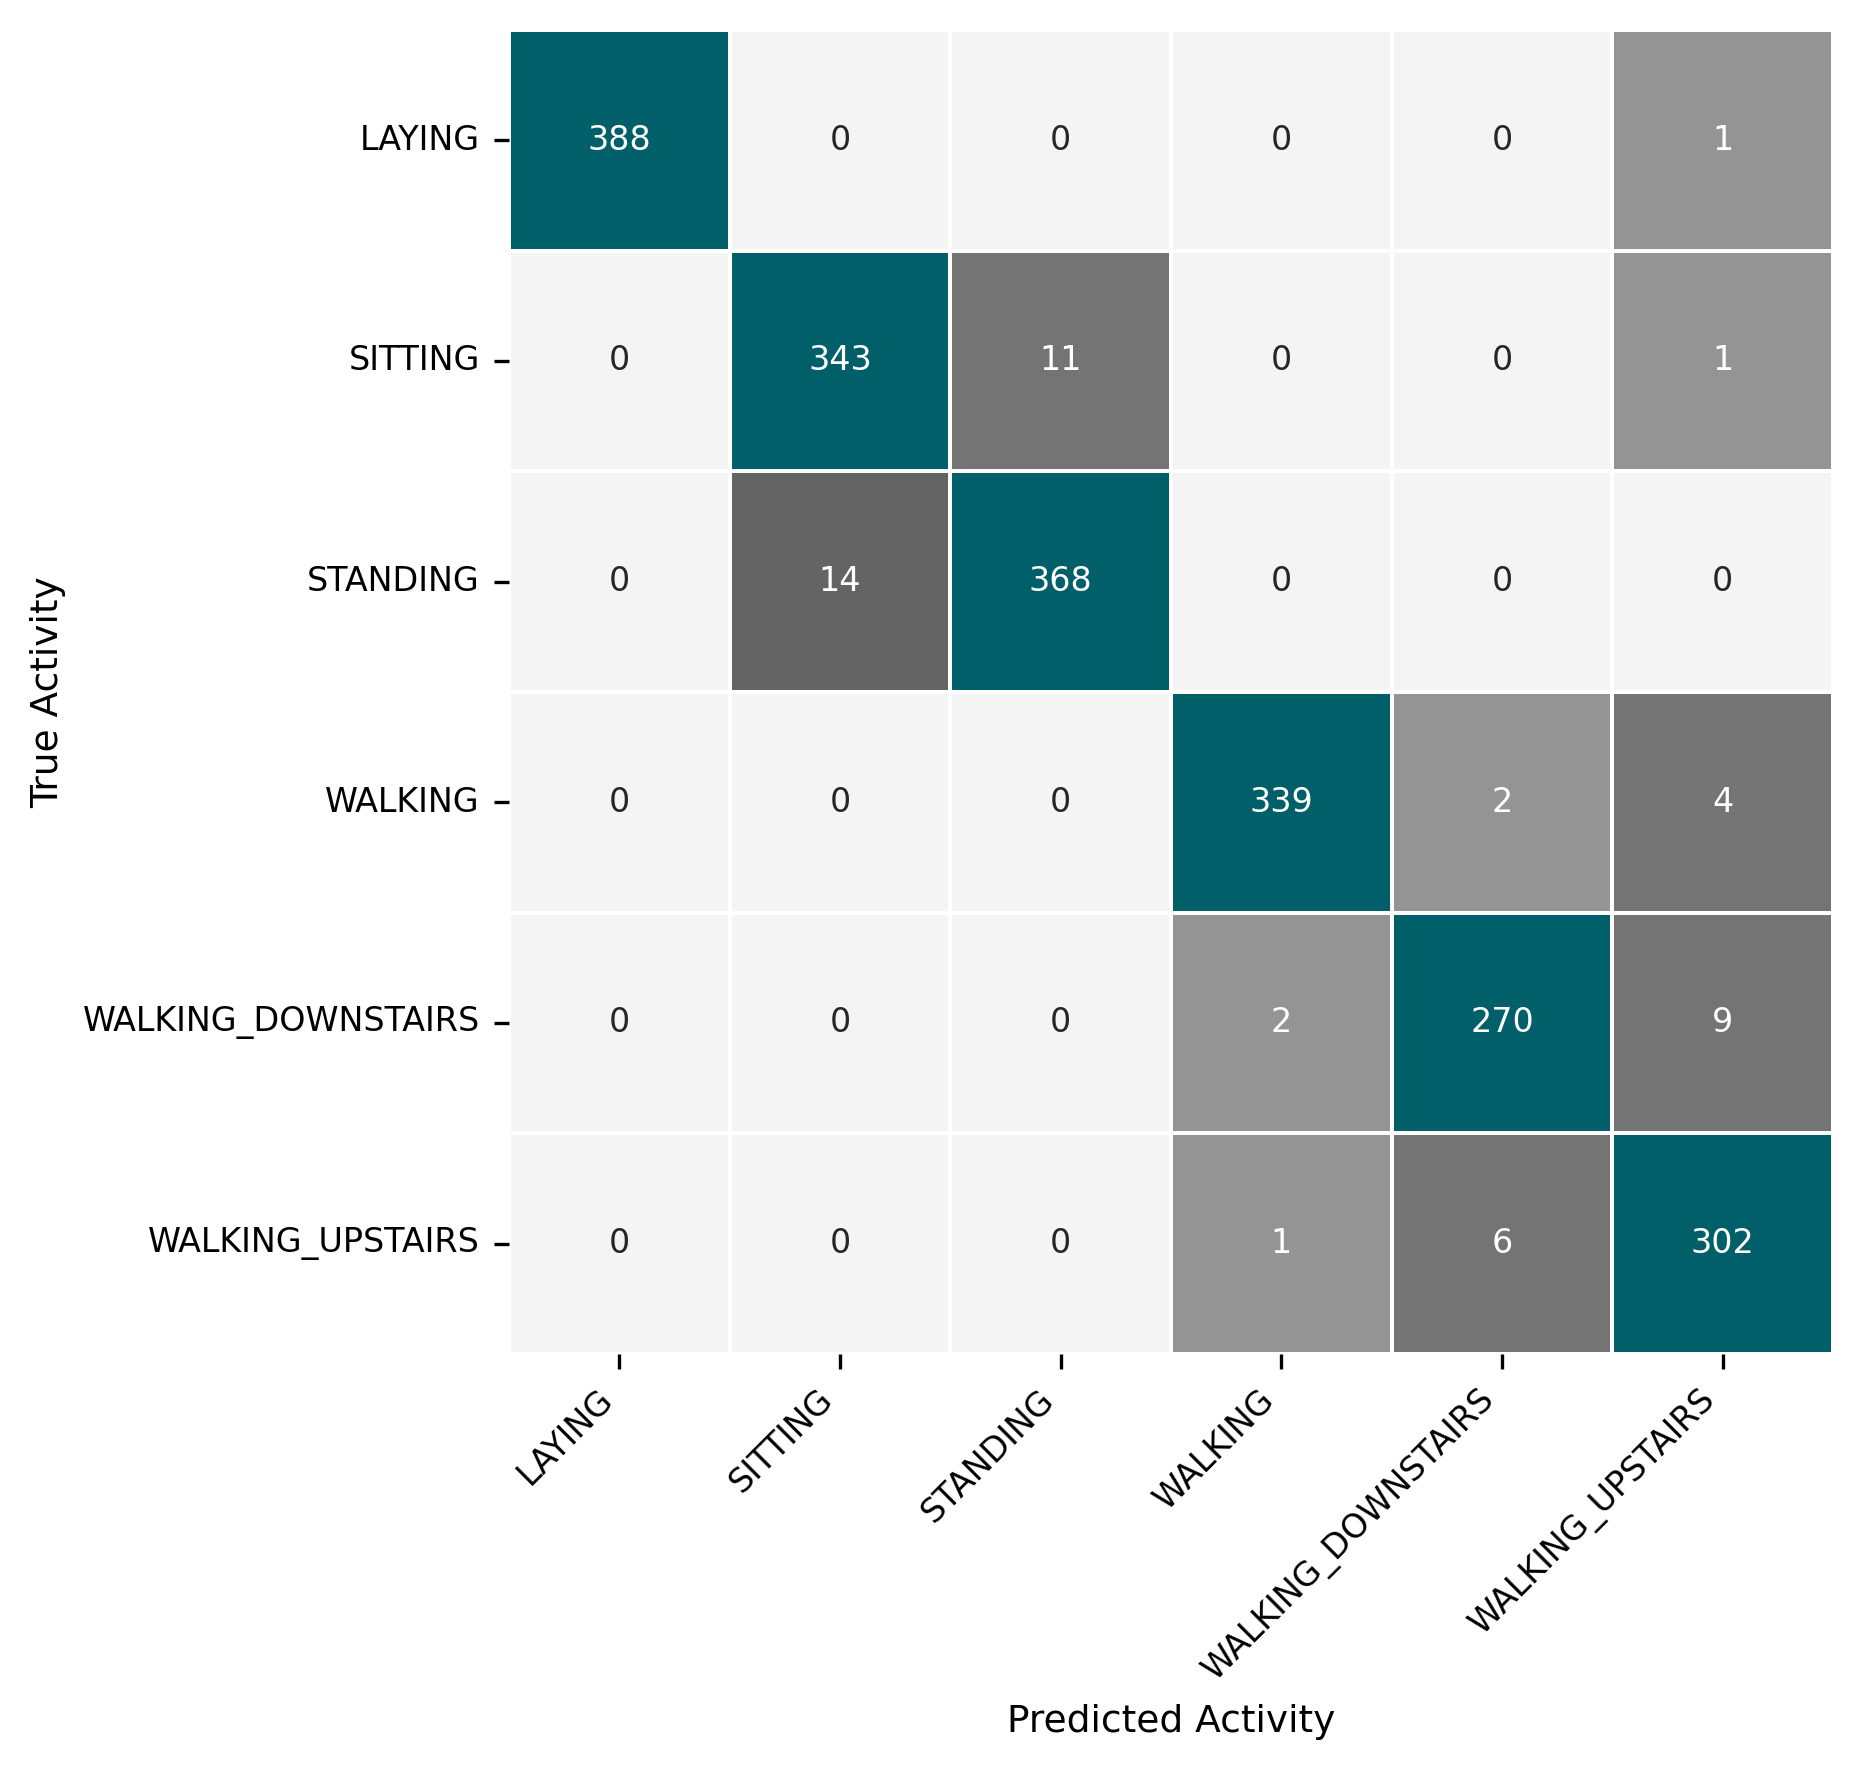

In [7]:
activity_order = sorted(np.unique(yte))
cm = confusion_matrix(yte, yte_hat, labels=activity_order)
cm_df = pd.DataFrame(cm, index=activity_order, columns=activity_order)

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

custom_colors = ['#F4F4F4', '#D4D4D4', '#B4B4B4', '#949494', '#747474',
                 '#646464', '#545454', '#444444', '#2B2B2B', '#005F69']
custom_cmap = sns.color_palette(custom_colors, as_cmap=True)
norm = PowerNorm(gamma=0.2, vmin=0, vmax=cm.max())

sns.heatmap(
    cm_df, annot=True, fmt='d', cmap=custom_cmap, cbar=False,
    linewidths=0.5, linecolor='white',
    annot_kws={'fontsize': 8, 'fontfamily': 'FiraSans'},
    norm=norm, ax=ax, square=True
)

ax.set_xlabel('Predicted Activity', fontsize=9, fontweight='normal', fontfamily='FiraSans')
ax.set_ylabel('True Activity', fontsize=9, fontweight='normal', fontfamily='FiraSans')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.set_xticklabels(activity_order, rotation=45, ha='right', fontsize=8, fontfamily='FiraSans')
ax.set_yticklabels(activity_order, rotation=0, fontsize=8, fontfamily='FiraSans')
plt.tight_layout()
plt.show()

## Feature Importance (Top 20)

findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


...

findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


findfont: Font family 'FiraSans' not found.


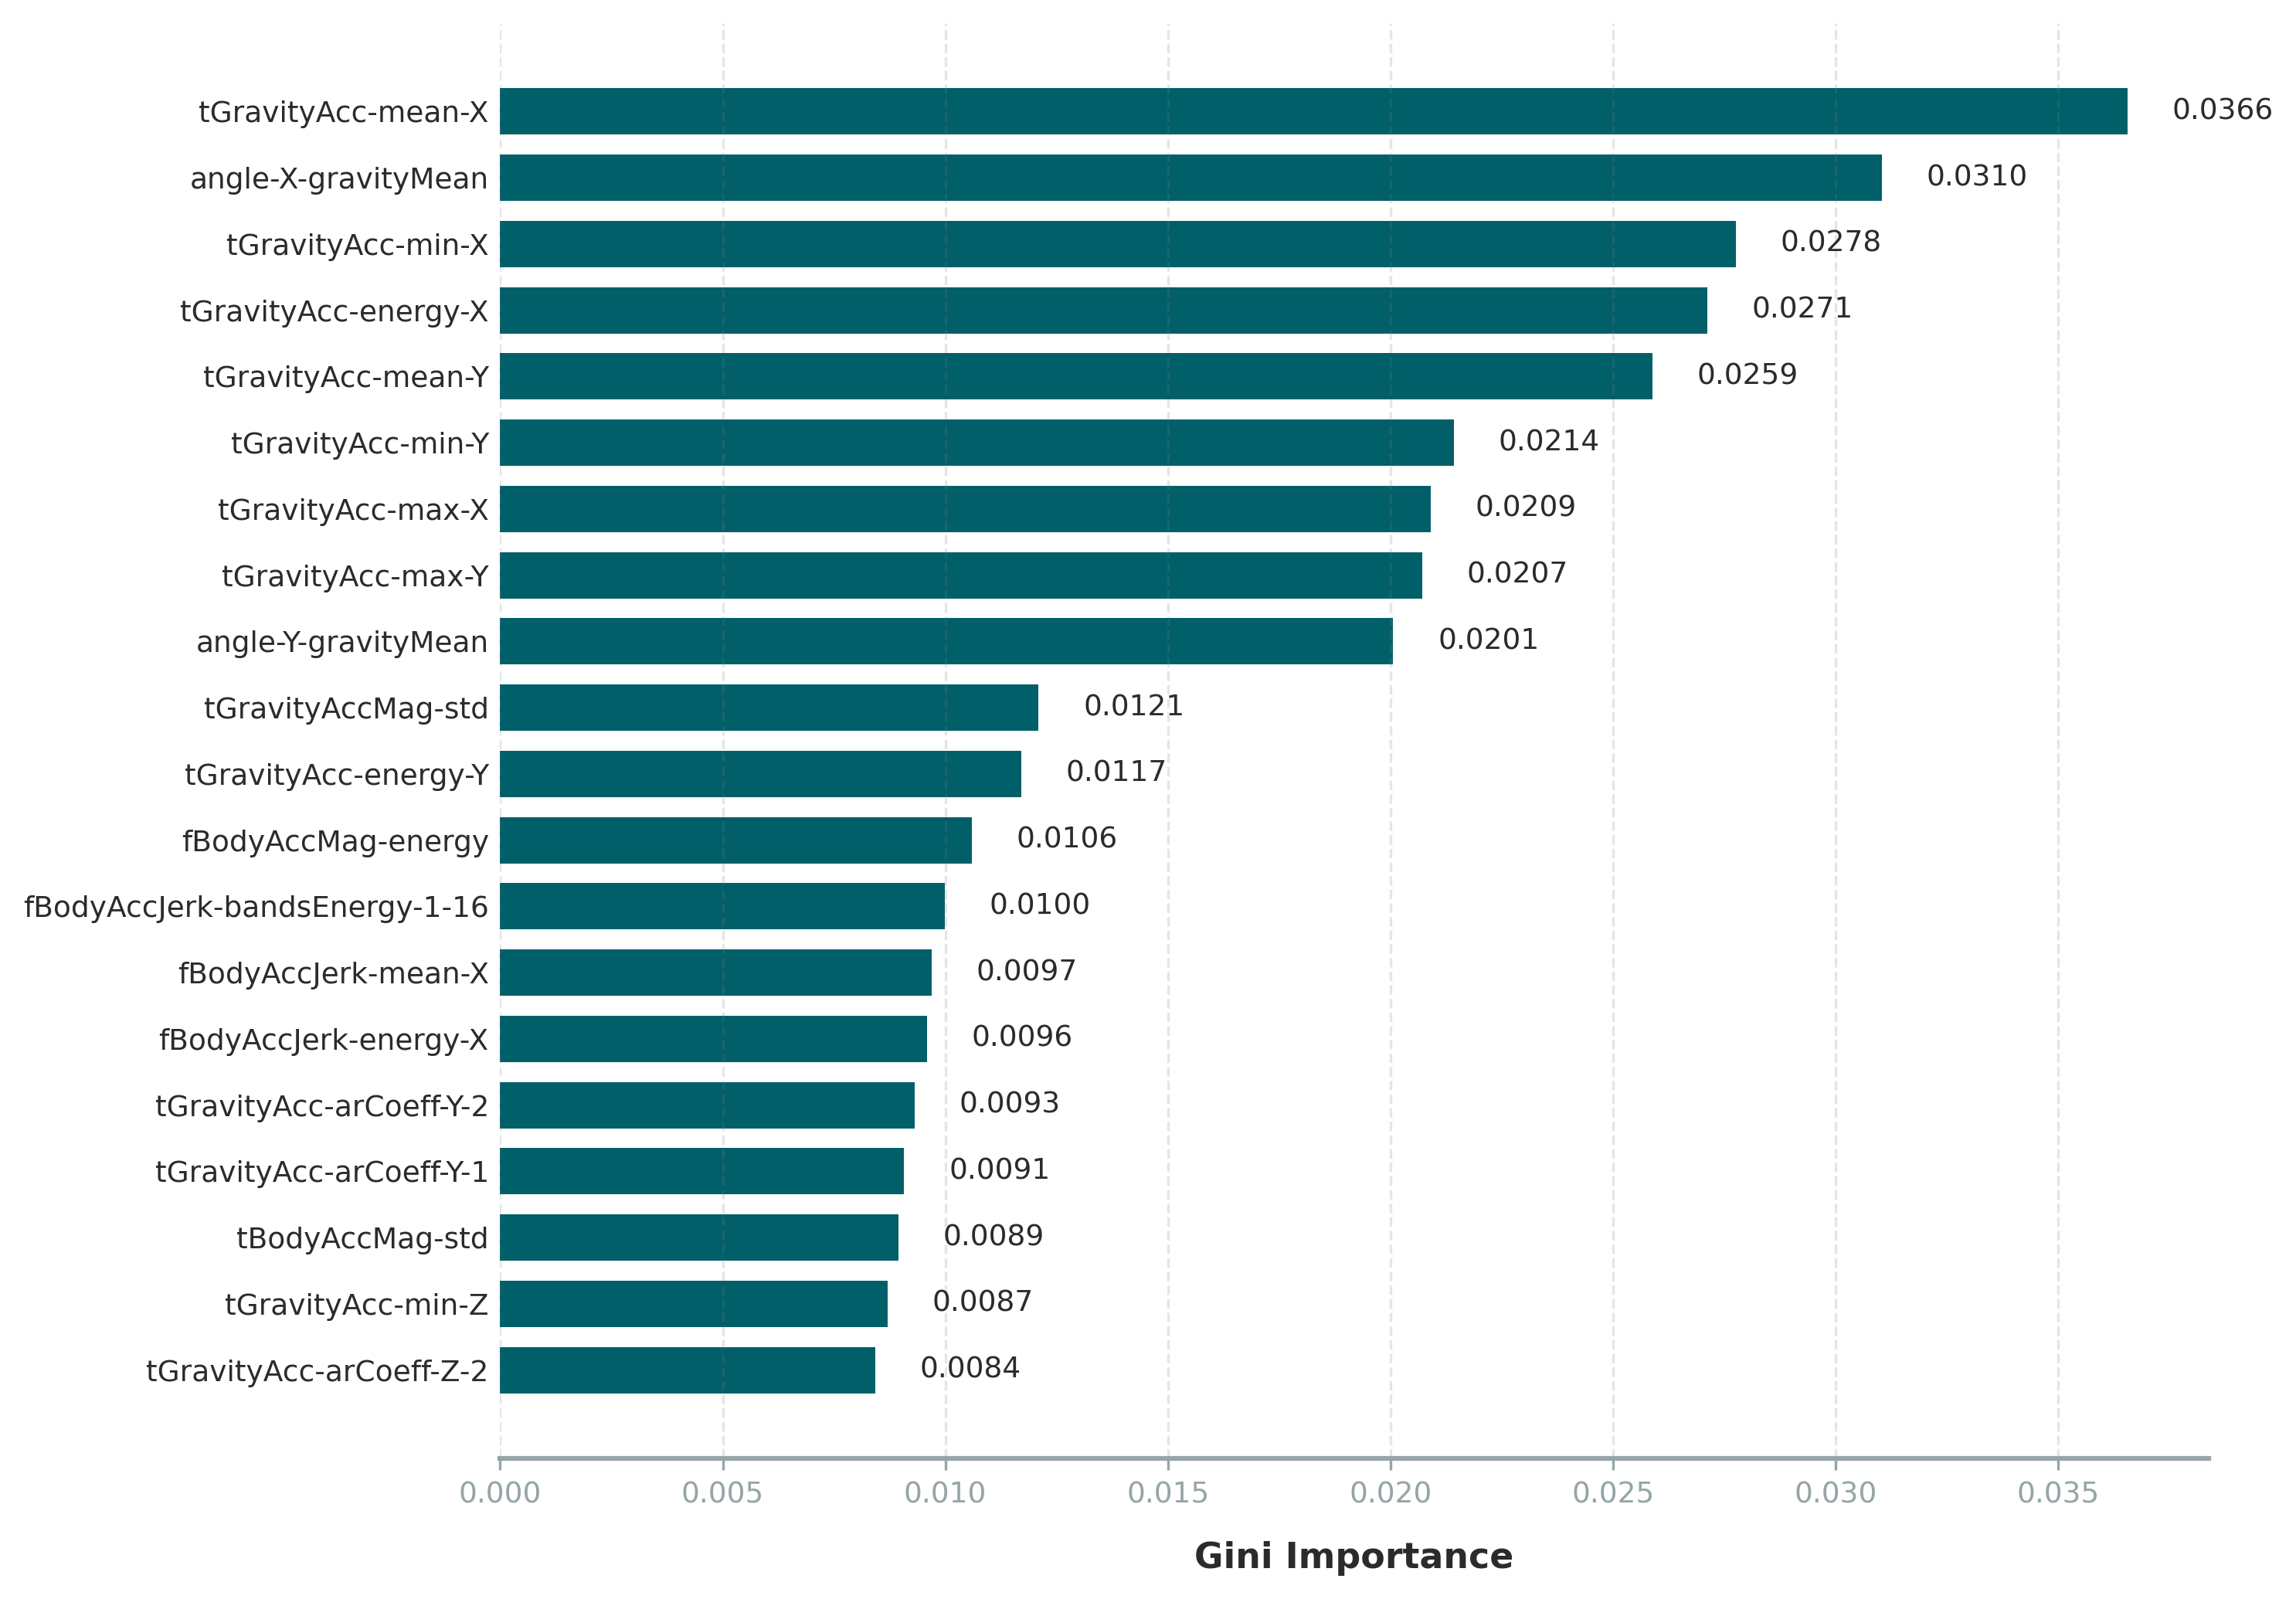

In [8]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

top_names = [feature_names[i] for i in indices][::-1]
top_values = importances[indices][::-1]

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

ax.barh(range(len(top_names)), top_values, color='#005f69', height=0.7, edgecolor='none')

for i, val in enumerate(top_values):
    ax.text(val + 0.001, i, f"{val:.4f}", va='center', fontsize=9,
            color='#2b2b2b', fontfamily='FiraSans')

ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=9, color='#2b2b2b', fontfamily='FiraSans')
ax.set_xlabel('Gini Importance', fontsize=11, fontweight='bold',
              color='#2b2b2b', labelpad=10, fontfamily='FiraSans')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#95a5a6')
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='x', colors='#95a5a6', labelsize=9)
ax.tick_params(axis='y', length=0)
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)

fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

## Hyperparameter Analysis: n_estimators and max_depth

n_estimators=  50 | Val: 0.9786 | Test: 0.9719


n_estimators= 100 | Val: 0.9776 | Test: 0.9738


n_estimators= 200 | Val: 0.9786 | Test: 0.9757


n_estimators= 300 | Val: 0.9796 | Test: 0.9753


n_estimators= 500 | Val: 0.9806 | Test: 0.9762


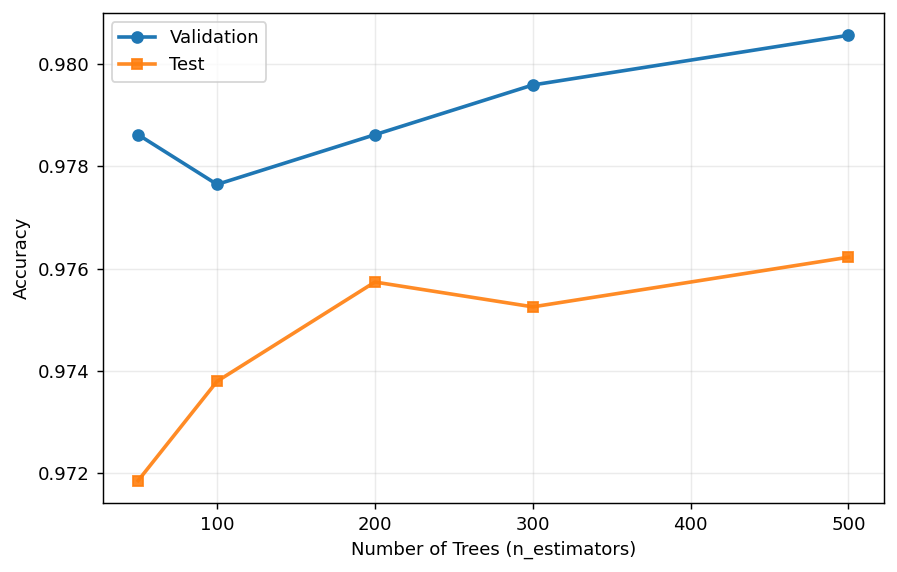

In [9]:
# Sweep over n_estimators
n_est_values = [50, 100, 200, 300, 500]
est_results = []

for n in n_est_values:
    clf_tmp = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                      random_state=42, n_jobs=-1)
    clf_tmp.fit(Xtr, ytr)
    va = accuracy_score(yva, clf_tmp.predict(Xva))
    te = accuracy_score(yte, clf_tmp.predict(Xte))
    est_results.append((n, va, te))
    print(f"n_estimators={n:>4d} | Val: {va:.4f} | Test: {te:.4f}")

df_est = pd.DataFrame(est_results, columns=["n_estimators", "val_acc", "test_acc"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_est["n_estimators"], df_est["val_acc"], marker='o', lw=2, label="Validation")
ax.plot(df_est["n_estimators"], df_est["test_acc"], marker='s', lw=2, label="Test", alpha=0.9)
ax.set_xlabel("Number of Trees (n_estimators)")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.25)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

max_depth=    5 | Val: 0.9359 | Test: 0.9262


max_depth=   10 | Val: 0.9757 | Test: 0.9665


max_depth=   15 | Val: 0.9796 | Test: 0.9728


max_depth=   20 | Val: 0.9796 | Test: 0.9772


max_depth=   30 | Val: 0.9796 | Test: 0.9753


max_depth= None | Val: 0.9796 | Test: 0.9753


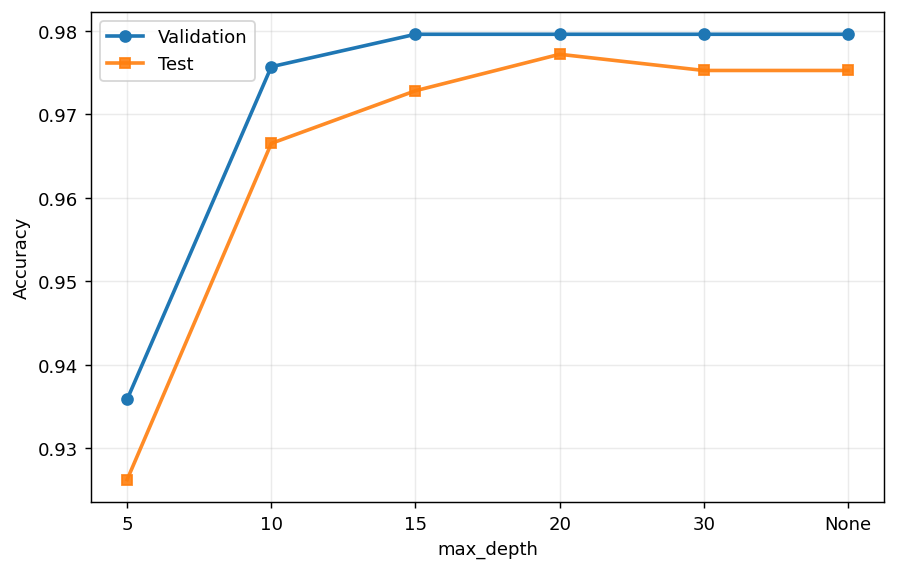

In [10]:
# Sweep over max_depth
depth_values = [5, 10, 15, 20, 30, None]
depth_results = []

for d in depth_values:
    clf_tmp = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                      max_depth=d, random_state=42, n_jobs=-1)
    clf_tmp.fit(Xtr, ytr)
    va = accuracy_score(yva, clf_tmp.predict(Xva))
    te = accuracy_score(yte, clf_tmp.predict(Xte))
    depth_results.append((str(d), va, te))
    print(f"max_depth={str(d):>5s} | Val: {va:.4f} | Test: {te:.4f}")

df_depth = pd.DataFrame(depth_results, columns=["max_depth", "val_acc", "test_acc"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(df_depth)), df_depth["val_acc"], marker='o', lw=2, label="Validation")
ax.plot(range(len(df_depth)), df_depth["test_acc"], marker='s', lw=2, label="Test", alpha=0.9)
ax.set_xticks(range(len(df_depth)))
ax.set_xticklabels(df_depth["max_depth"])
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.25)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## OOB Error Analysis

Out-of-Bag (OOB) error provides an unbiased estimate of the generalization error without needing a separate validation set. Each tree in the forest is trained on a bootstrap sample, and the OOB estimate uses predictions from trees that did not include a given sample in their training set.

/Users/batu/anaconda/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=  10 | OOB Accuracy: 0.9225


n_estimators=  25 | OOB Accuracy: 0.9655


n_estimators=  50 | OOB Accuracy: 0.9723


n_estimators= 100 | OOB Accuracy: 0.9741


n_estimators= 150 | OOB Accuracy: 0.9752


n_estimators= 200 | OOB Accuracy: 0.9760


n_estimators= 300 | OOB Accuracy: 0.9760


n_estimators= 500 | OOB Accuracy: 0.9768


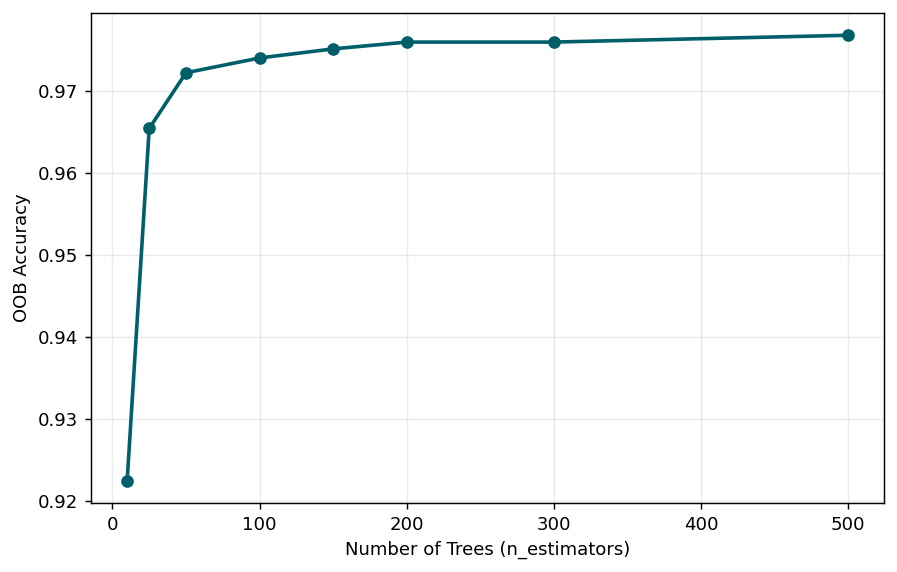

In [11]:
# OOB score vs n_estimators
oob_values = [10, 25, 50, 100, 150, 200, 300, 500]
oob_results = []

for n in oob_values:
    clf_tmp = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                      random_state=42, n_jobs=-1, oob_score=True)
    clf_tmp.fit(Xtr, ytr)
    oob_results.append((n, clf_tmp.oob_score_))
    print(f"n_estimators={n:>4d} | OOB Accuracy: {clf_tmp.oob_score_:.4f}")

df_oob = pd.DataFrame(oob_results, columns=["n_estimators", "oob_score"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_oob["n_estimators"], df_oob["oob_score"], marker='o', lw=2, color='#005f69')
ax.set_xlabel("Number of Trees (n_estimators)")
ax.set_ylabel("OOB Accuracy")
ax.grid(True, alpha=0.25)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## Model Comparison: Random Forest vs Logistic Regression

In [12]:
comparison_data = {
    "Model": ["Multinomial Logistic Regression", "Random Forest (300 trees)"],
    "Val Accuracy": [0.9854, val_acc],
    "Test Accuracy": [0.9825, test_acc],
    "Features": [561, 561],
    "Notes": ["PCA optional, linear model", "Ensemble of decision trees, OOB available"]
}

df_comp = pd.DataFrame(comparison_data)
display(df_comp)

,Model,Val Accuracy,Test Accuracy,Features,Notes
0,Multinomial Logistic Regression,0.985400,0.982500,561,"PCA optional, linear model"
1,Random Forest (300 trees),0.979592,0.975255,561,"Ensemble of decision trees, OOB available"


## Summary

**Key Findings:**

1. **Random Forest** provides competitive performance on the UCI-HAR dataset, leveraging ensemble diversity from bootstrap aggregating and random feature subsampling.

2. **Feature Importance** analysis reveals which sensor features contribute most to activity discrimination, offering interpretability that complements the model's ensemble nature.

3. **OOB Error** provides a convenient, built-in estimate of generalization performance without requiring a separate validation set.

4. **Comparison with Logistic Regression:** The Multinomial LR baseline (98.25%) leverages the near-linear separability of the well-engineered UCI-HAR features. Random Forest's strength lies in capturing nonlinear interactions, but the hand-crafted features in this dataset already encode much of the relevant structure.

5. **Literature Context:** Zaki et al. (2020) reported RF accuracy of 92.40% on UCI-HAR. Our result improves upon this, likely due to careful preprocessing (z-score normalization fitted only on training data, stratified splitting).